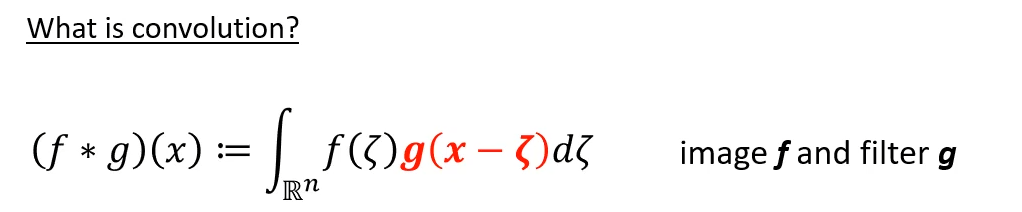

- kernel iterates thru the image coordinate: 
    - multiply matrix values pixelwise
    - sum up the products
    - value of the new matrix : output channel 

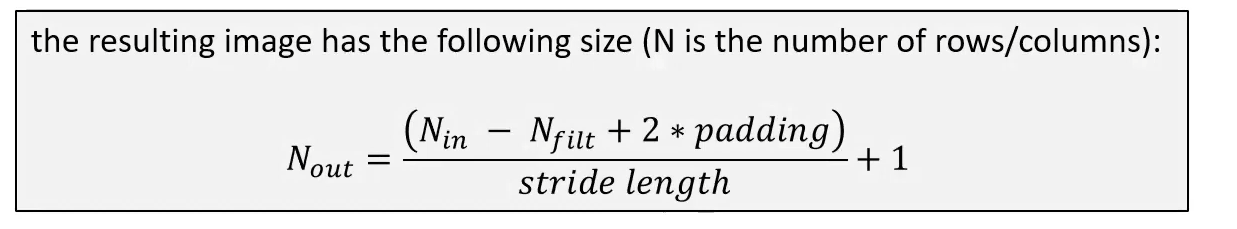

- there are fixed-predefined kernels e.g. vertical edge detectors, horizontal detectors, background detectors, they all serve as specific feature extractor
- and there is another type of kernels, whose weights are learnable, which serves similar to neurons in ANN or cell in RNN

### lets load our images : ten-animals

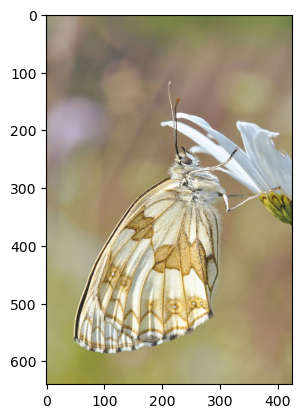

In [1]:
import os 
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

main_data_path = r"C:\Users\ayhan\Desktop\ml-collection\data"
ten_animals_dataset_path = os.path.join(main_data_path, "ten_animals","raw-img")

animal = "butterfly"
animal_path = os.path.join(ten_animals_dataset_path, animal)
animal_images = glob.glob(os.path.join(animal_path, "*"))
selected_animal_img = animal_images[0]
img_format = "jpg"
img = plt.imread(selected_animal_img)
plt.imshow(img,cmap="gray")

In [2]:
# lets create a func to return a random image from a given animal
def get_random_image(animal:str, img_format:str="jpg"):
    animal_path = os.path.join(ten_animals_dataset_path, animal)
    animal_images = glob.glob(os.path.join(animal_path, "*"))
    selected_animal_img = animal_images[np.random.randint(0,len(animal_images))]
    img = plt.imread(selected_animal_img)
    return img

In [3]:
img = get_random_image("butterfly")
type(img), img.shape, img.dtype, (img.min(), img.max())

(numpy.ndarray, (426, 640, 3), dtype('uint8'), (0, 255))

##### * so for 3 channel 8-bit representation can generate 256^3 = 16.7M colors

In [4]:
# lets convert uint8 to float32
img = img.astype(np.float32)

In [46]:
(img.min(), img.max())

(0.0, 255.0)

##### Bit Depth:

- Digital images are stored using a certain number of bits per pixel, which defines the "bit depth" of the image. The bit depth determines the number of possible intensity levels for each pixel.
- A common bit depth for grayscale or color channels in images is 8 bits.

- each pixel can have a value ranging from 2^0-1 = 0 (pure black) to 2^8-1 = 255 (pure white), representing 256 possible intensity levels.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


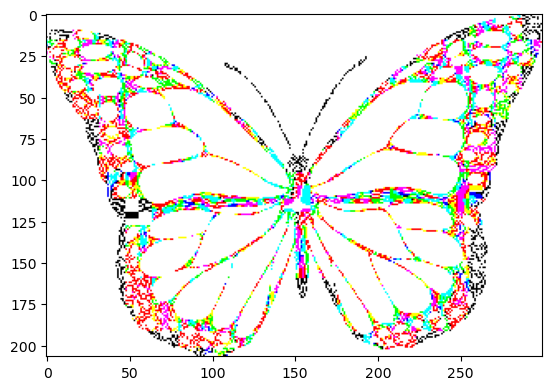

In [5]:
#  Changing Bit Depth
img = get_random_image("butterfly")
img_16bit = (img.astype(np.uint16) * 257)
plt.imshow(img_16bit, cmap="gray")

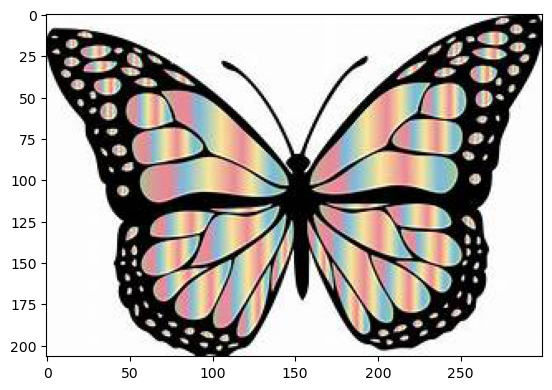

In [6]:
# or we can normalize the image which is way common in computer vision data preprocessing pipelines
normalized_img = img / 255.0
plt.imshow(normalized_img, cmap="gray")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


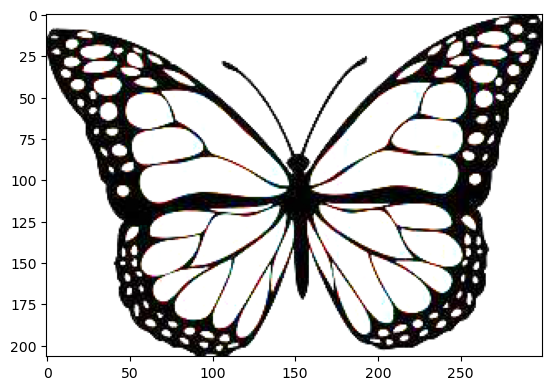

In [7]:
normalized_img2 = (img / 255.0)*2
plt.imshow(normalized_img2, cmap="gray")

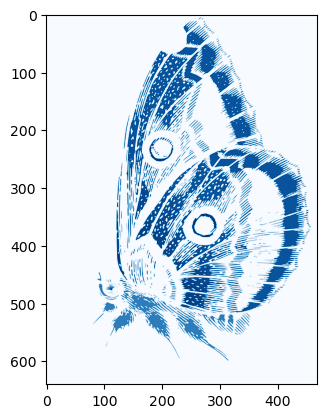

In [30]:
img = get_random_image("butterfly")
img = img[:,:,2]
plt.imshow(img,cmap="Blues")

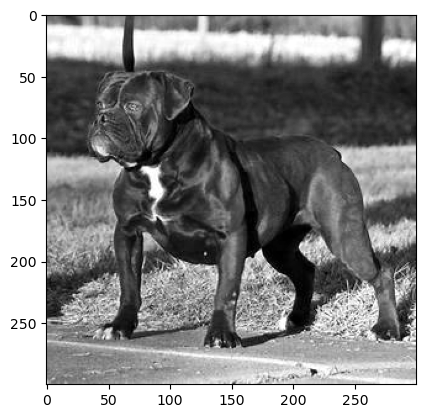

In [32]:
# lets remove the third channel
img = get_random_image("dog")
img = img[:,:,0]
plt.imshow(img,cmap="gray")


### now lets create our convolution class, which can apply various predefined kernels

In [8]:
from scipy.signal import convolve2d
from typing import Union, Tuple, List
class ManualKernelConvolution:
    def __init__(self, image:Union[np.ndarray,str],):
        if isinstance(image, str):
            try:
                self.image = plt.imread(image)
            except:
                raise Exception("Invalid image path")
        else:
            self.image = image
        print("loaded image:")
        plt.imshow(self.image, cmap="gray")
        self.n_channels = self.image.shape[2]
        self.kernels = []
        self.n_kernels = 0
        self.channel_map = {
            0:"Red",
            1:"Green",
            2:"Blue"
        }

    def convolve(self,kernels:List[Tuple[str,np.ndarray]]):
        self.kernels = kernels # a kernel has a name and a numpy array
        self.n_kernels = len(kernels)
        grid_size = np.math.ceil(np.math.sqrt(self.n_kernels)) # square grid
        for i in range(self.n_channels):
            plt.figure(figsize=(12,8))
            plt.suptitle(f"applied convolution for channel {self.channel_map[i]}")
            plt.subplots_adjust(hspace=0.5)
            for idx,(name, kernel) in enumerate(self.kernels):
                plt.subplot(grid_size, grid_size, idx+1)
                conv_img = convolve2d(self.image[:,:,i], kernel, mode="same")
                plt.imshow(conv_img, cmap="gray")
                plt.title(name)
            plt.show()


loaded image:


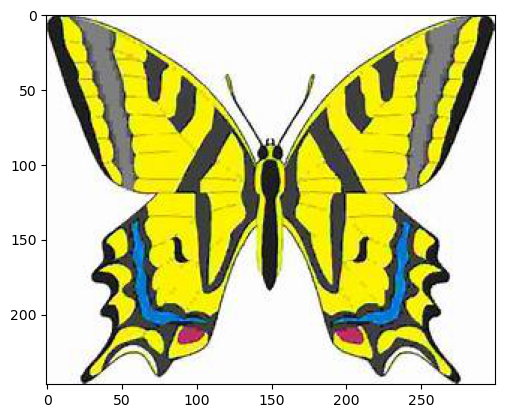

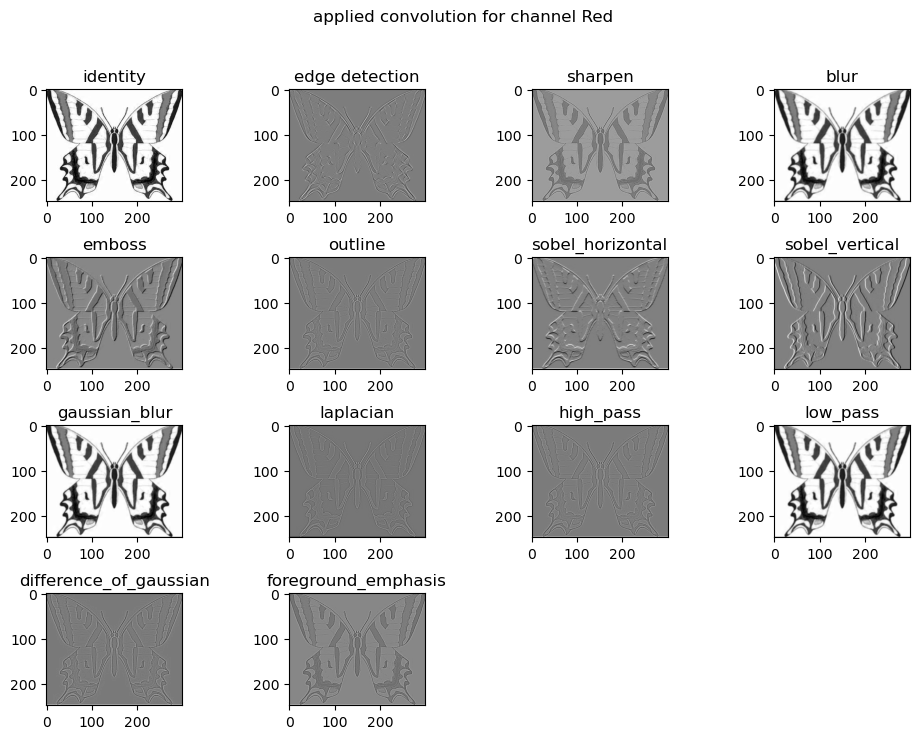

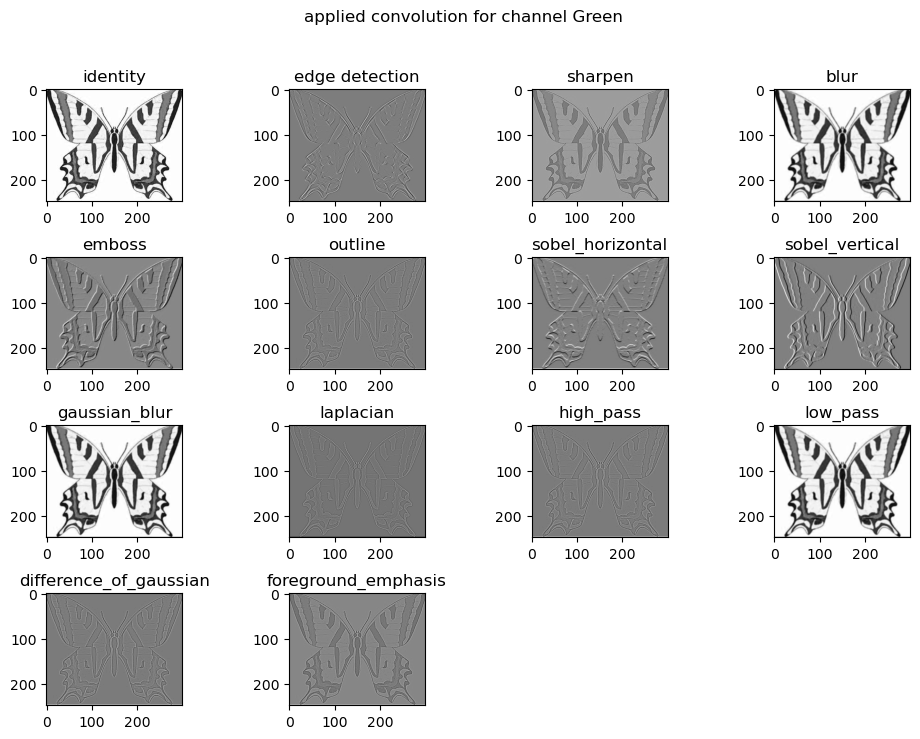

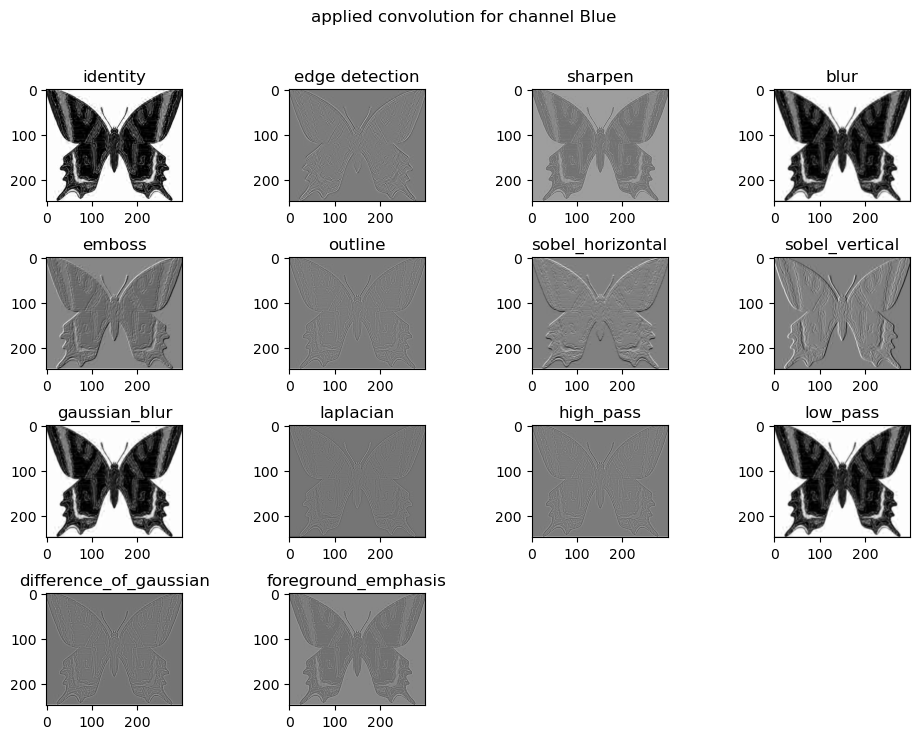

In [74]:
img = get_random_image("butterfly")
manual_conv = ManualKernelConvolution(img)
# define kernels as a list of tuples
kernels = [
    ("identity", np.array([[0,0,0], [0,1,0], [0,0,0]])),
    ("edge detection", np.array([[1,0,-1], [0,0,0], [-1,0,1]])),
    ("sharpen", np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])),
    ("blur", np.array([[1,1,1], [1,1,1], [1,1,1]])/9),
    ("emboss", np.array([[-2,-1,0], [-1,1,1], [0,1,2]])),
    ("outline", np.array([[-1,-1,-1], [-1,8,-1], [-1,-1,-1]])),
    ("sobel_horizontal", np.array([[-1,-2,-1], [0,0,0], [1,2,1]])),
    ("sobel_vertical", np.array([[-1,0,1], [-2,0,2], [-1,0,1]])),
    ("gaussian_blur", np.array([[1,2,1], [2,4,2], [1,2,1]])/16),
    ("laplacian", np.array([[0,1,0], [1,-4,1], [0,1,0]])),    
    # Background-foreground separation
    ("high_pass", np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])),
    ("low_pass", np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]])/9),
    ("difference_of_gaussian", np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]])/16 - 
                               np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]])/9),
    ("foreground_emphasis", np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]]))
]

manual_conv.convolve(kernels)

###  keep in mind that our implemented convolutional neural network will not get these filters specified in hand, instead the kernels will be initialized at random and the network will learn the weights by itself